## Data Analytics 




In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


In [ ]:
# Tech tickers (2 additional)
df1=yf.download("AAPL",start="2020-01-01",end="2025-01-01")
df2=yf.download("TSLA",start="2020-01-01",end="2025-01-01")
df_msft=yf.download("MSFT",start="2020-01-01",end="2025-01-01")  # Microsoft - Tech
df_nvda=yf.download("NVDA",start="2020-01-01",end="2025-01-01")  # NVIDIA - Tech

# Various industries (6 tickers)
df_jpm=yf.download("JPM",start="2020-01-01",end="2025-01-01")  # JPMorgan Chase - Finance
df_jnj=yf.download("JNJ",start="2020-01-01",end="2025-01-01")  # Johnson & Johnson - Healthcare
df_wmt=yf.download("WMT",start="2020-01-01",end="2025-01-01")  # Walmart - Retail/Consumer
df_xom=yf.download("XOM",start="2020-01-01",end="2025-01-01")  # Exxon Mobil - Energy
df_ba=yf.download("BA",start="2020-01-01",end="2025-01-01")   # Boeing - Industrial/Aerospace
df_ko=yf.download("KO",start="2020-01-01",end="2025-01-01")   # Coca-Cola - Consumer Staples

# Drop NaN values
for df in [df1, df2, df_msft, df_nvda, df_jpm, df_jnj, df_wmt, df_xom, df_ba, df_ko]:
    df.dropna(inplace=True)

In [66]:
# Combine all tickers into one MultiIndex DataFrame
df_large = pd.concat([df1, df2, df_msft, df_nvda, df_jpm, df_jnj, df_wmt, df_xom, df_ba, df_ko], axis=1).drop_duplicates()
df_large.head()

Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,TSLA,TSLA,TSLA,TSLA,TSLA,...,BA,BA,BA,BA,BA,KO,KO,KO,KO,KO
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.468254,72.528574,71.223252,71.476592,135480400,28.684000,28.713333,28.114000,28.299999,142981500,...,331.348572,331.378393,325.761816,326.606765,4544400,45.745106,46.111132,45.553770,46.019625,11867700
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800,29.534000,30.266666,29.128000,29.366667,266677500,...,330.791901,332.909308,328.346428,328.674494,3875900,45.495533,45.745100,44.996406,45.187738,11354500
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200,30.102667,30.104000,29.333332,29.364668,151995000,...,331.766083,332.879454,325.940756,327.352341,5355000,45.478905,45.678557,45.354125,45.462270,14698300
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000,31.270666,31.441999,30.224001,30.760000,268231500,...,335.285156,342.154291,328.754007,332.283029,9898600,45.129513,45.420670,45.046326,45.295890,9973900
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200,32.809334,33.232666,31.215334,31.580000,467164500,...,329.410095,332.054366,327.650575,330.434002,8239200,45.212700,45.453946,45.046326,45.146151,10676000


## Efficient Data Extraction with MultiIndex .xs() Method

The `.xs()` (cross-section) method is an incredibly powerful tool for working with MultiIndex DataFrames in pandas. When you have hierarchical column structures (like Ticker and Price levels), `.xs()` allows you to extract specific slices along any axis and level with clean, readable syntax. 

- `key` (the value to select), 
- `axis` (0 for rows, 1 for columns)
-  `level` (the name or position of the MultiIndex level). 

This method is much more efficient than using `.loc[]` with complex tuple indexing, especially when you need to extract the same metric across all tickers or all prices for a specific ticker.

One of the most powerful aspects of `.xs()` is its ability to work seamlessly with pandas operations. After extracting a cross-section, you can immediately chain statistical methods, plotting functions, or transformations without creating intermediate variables. This makes exploratory data analysis on large MultiIndex DataFrames both readable and performant. For example, you can extract all "Close" prices across all tickers, calculate returns, and then compute correlation matrices—all in a single, elegant pipeline.

Ticker
AAPL    0.276474
TSLA    0.391047
MSFT    0.283696
NVDA    0.994484
JPM     0.279218
JNJ     0.082297
WMT     0.242135
XOM     0.392991
BA      0.206765
KO      0.141943
dtype: float64

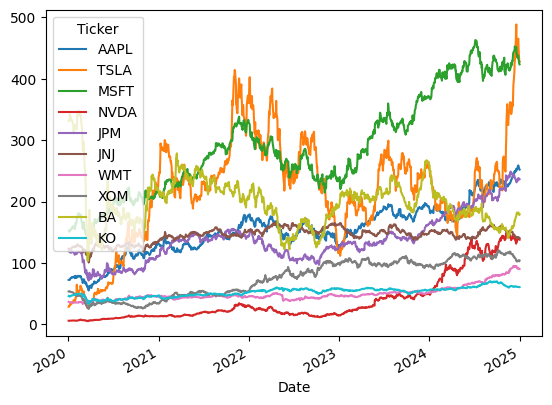

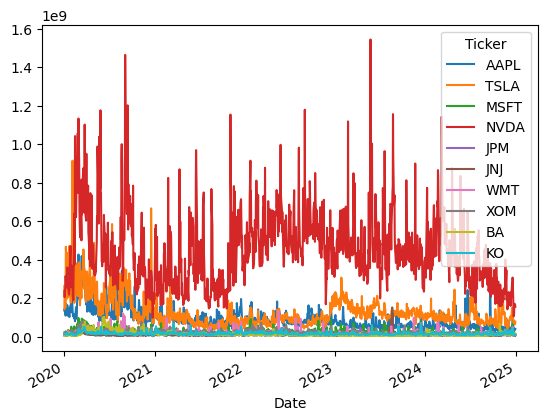

In [67]:
# df_large.xs(key="AAPL", axis=1, level='Ticker')
# df_large.xs("Close", axis=1, level='Price')
df_large.xs("High", axis=1, level='Price').plot()
df_large.xs("Volume", axis=1, level='Price').plot()

# Statistical insights using .xs method
df_large.xs("Close", axis=1, level='Price').pct_change().corr()  # Correlation matrix of daily returns
df_large.xs("Close", axis=1, level='Price').rolling(20).mean().tail()  # 20-day moving averages
df_large.xs("Volume", axis=1, level='Price').sum().sort_values(ascending=False)  # Total volume by ticker
df_large.xs("High", axis=1, level='Price').max() - df_large.xs("Low", axis=1, level='Price').min()  # Price ranges
df_large.xs("Close", axis=1, level='Price').std() / df_large.xs("Close", axis=1, level='Price').mean()  # Coefficient of variation


In [62]:
df_large.xs("Close", axis=1, level='Price').loc["2023-01-01":][["AAPL"]]
# df.xs("Close", axis=1, level='Price').loc["2023-01-01":]

Ticker,AAPL
Date,
2023-01-03,123.211205
2023-01-04,124.482040
2023-01-05,123.161942
2023-01-06,127.693596
2023-01-09,128.215714
...,...
2024-12-24,257.037506
2024-12-26,257.853790
2024-12-27,254.439240


In [ ]:
#  gENERAL FILTERS WITH DATA FRAME
df = yf.download("AAPL",start="2010-01-01")
# df.head()
# say i want close from 2023, key is close b/c that's what I want, axis is 1 b/c it's a column, level is price b/c that's the column level
df.xs("Close", axis=1, level='Price').loc["2023-01-01":]
# this will fail b/c close is a column, but ticker is a row level 
# df.xs("Close", axis=1, level='Ticker').loc["2023-01-01":]
# this will work b/c it's a row level


# df_close.xs("Close", axis= 1, level='Ticker')

df.xs("AAPL", axis=1, level='Ticker')





/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/2593881931.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL",start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.418382,6.433077,6.369496,6.400987,493729600
2010-01-05,6.429479,6.465768,6.395589,6.436077,601904800
2010-01-06,6.327210,6.454972,6.320612,6.429480,552160000
2010-01-07,6.315513,6.358101,6.269627,6.350603,477131200
2010-01-08,6.357500,6.358100,6.269927,6.307115,447610800
...,...,...,...,...,...
2025-12-15,274.109985,280.149994,272.839996,280.149994,50409100
2025-12-16,274.609985,275.500000,271.790009,272.820007,37648600
2025-12-17,271.839996,276.160004,271.640015,275.010010,50138700


In [ ]:
df_close = df.xs("Close", axis=1, level='Price').loc["2023-01-01":]
df_close.reset_index()
df_close.reset_index()['AAPL'].values
# with multi-index, you can use .xs to get series with 
series = pd.Series(df_close.reset_index()['AAPL'].values, index=df_close.reset_index()['Date'])
series






Date
2023-01-03    123.211205
2023-01-04    124.482033
2023-01-05    123.161949
2023-01-06    127.693565
2023-01-09    128.215683
                 ...    
2025-12-15    274.109985
2025-12-16    274.609985
2025-12-17    271.839996
2025-12-18    272.190002
2025-12-19    273.670013
Length: 745, dtype: float64

In [64]:
# REFRESHER ON SHIFTING DATA
df = yf.download("AAPL",start="2010-01-01")
df.xs("Close", axis=1, level='Price').shift(1)

/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/676359414.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL",start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2010-01-04,NaN
2010-01-05,6.418383
2010-01-06,6.429479
2010-01-07,6.327209
2010-01-08,6.315512
...,...
2025-12-15,278.279999
2025-12-16,274.109985
2025-12-17,274.609985


In [68]:
df['Ret'] = df.xs("Close", axis=1, level='Price').pct_change()

In [89]:
df.xs("Open", axis=1, level='Price').diff()
open_diff = df.xs("Open", axis=1, level='Price').diff().reset_index()
open_diff.columns = ['Date', 'Open_Diff']
open_diff.dropna(inplace=True)
open_diff.head()
# df['open_diff'] = open_diff.reset_index()['KO']
# open_diff # i'm taking the differences between the open and close prices


,Date,Open_Diff
1,2020-01-06,0.274532
2,2020-01-07,-0.166380
3,2020-01-08,-0.149738
4,2020-01-09,0.607280
5,2020-01-10,0.399297


(1257, 6)


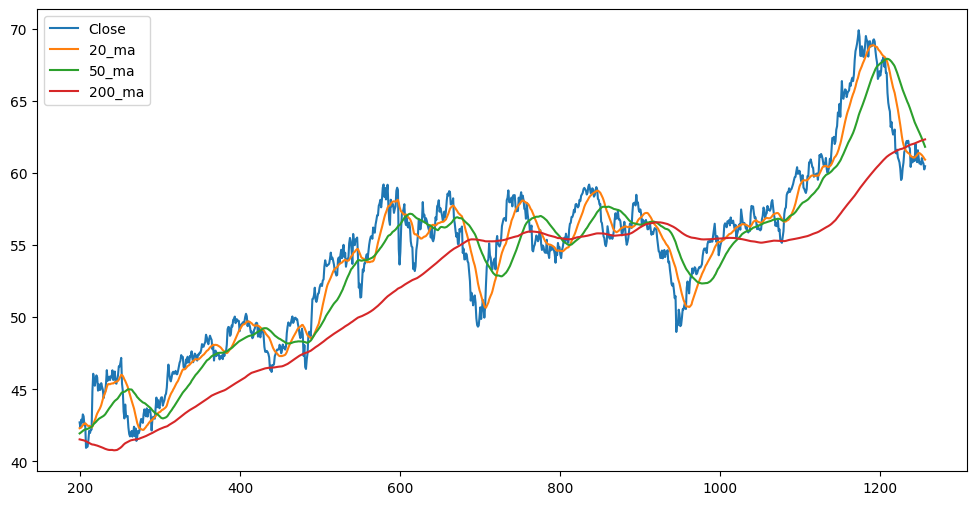

In [ ]:
# Creating Rolling Window with YF Data frames multio index 
# THIS IS ANNOYING but we can put gogether (YFINANCE Utilities to make them.  I'ts great api for global macro data)
print(df.shape)
close = df.xs("Close", axis=1, level='Price').reset_index()
close.columns = ['Date', 'Close']
close['Close'].rolling(window=20).mean().dropna() # 20 day moving average
close['20_ma'] = close['Close'].rolling(window=20).mean().dropna()
close['50_ma'] = close['Close'].rolling(window=50).mean().dropna()
close['200_ma'] = close['Close'].rolling(window=200).mean().dropna()
close = close.dropna()
close.tail()
close[["Close", "20_ma", "50_ma", "200_ma"]].plot(figsize=(12,6))
plt.show()




In [114]:
df_large.head()

Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,TSLA,TSLA,TSLA,TSLA,TSLA,...,BA,BA,BA,BA,BA,KO,KO,KO,KO,KO
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.468254,72.528574,71.223252,71.476592,135480400,28.684000,28.713333,28.114000,28.299999,142981500,...,331.348572,331.378393,325.761816,326.606765,4544400,45.745106,46.111132,45.553770,46.019625,11867700
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800,29.534000,30.266666,29.128000,29.366667,266677500,...,330.791901,332.909308,328.346428,328.674494,3875900,45.495533,45.745100,44.996406,45.187738,11354500
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200,30.102667,30.104000,29.333332,29.364668,151995000,...,331.766083,332.879454,325.940756,327.352341,5355000,45.478905,45.678557,45.354125,45.462270,14698300
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000,31.270666,31.441999,30.224001,30.760000,268231500,...,335.285156,342.154291,328.754007,332.283029,9898600,45.129513,45.420670,45.046326,45.295890,9973900
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200,32.809334,33.232666,31.215334,31.580000,467164500,...,329.410095,332.054366,327.650575,330.434002,8239200,45.212700,45.453946,45.046326,45.146151,10676000


In [124]:
# find day APPL was the largest  
# df_large.xs("Close", axis=1, level='Price')['AAPL'].nlargest(1)
# df_large.xs("Close", axis=1, level='Price')['AAPL'].nlargest(5)
df_large.xs("Close", axis=1, level='Price')['AAPL'].nsmallest(5)


Date
2020-03-23    54.264332
2020-03-20    55.442158
2020-04-01    58.264572
2020-04-03    58.385494
2020-03-16    58.578972
Name: AAPL, dtype: float64

In [126]:
df_large.xs("Close", axis=1, level='Price').reset_index().nlargest(5, "AAPL")

Ticker,Date,AAPL,TSLA,MSFT,NVDA,JPM,JNJ,WMT,XOM,BA,KO
1254,2024-12-26,257.853790,454.130005,434.901825,139.891739,238.099686,141.256042,91.910233,102.720032,180.380005,60.776882
1253,2024-12-24,257.037506,462.279999,436.112885,140.181656,237.286896,141.518036,91.801270,102.633224,179.339996,61.039146
1255,2024-12-27,254.439240,431.660004,427.377319,136.972534,236.170517,140.741791,90.790955,102.710396,180.720001,60.660324
1252,2024-12-23,254.120682,430.600006,432.062775,139.631790,233.448135,140.955261,89.493370,102.536766,177.690002,60.592327
1251,2024-12-20,253.344208,421.059998,433.402924,134.663162,232.674530,140.179016,91.365440,102.121986,177.350006,60.757450


In [ ]:
df_large.xs("Close", axis=1, level='Price')[["AAPL", "TSLA"]].nlargest(5, "Close")


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/1569846280.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2010-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/1569846280.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.xs("Close", axis=1, level='Price').resample("M").mean() # here we get the monthly price
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/1569846280.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.xs("Close", axis=1, level='Price').resample("M").mean().plot(figsize=(12,6))


Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.418385  6.433080  6.369499  6.400990  493729600
2010-01-05  6.429481  6.465770  6.395591  6.436079  601904800
2010-01-06  6.327211  6.454973  6.320613  6.429480  552160000
2010-01-07  6.315513  6.358101  6.269627  6.350603  477131200
2010-01-08  6.357502  6.358103  6.269929  6.307118  447610800


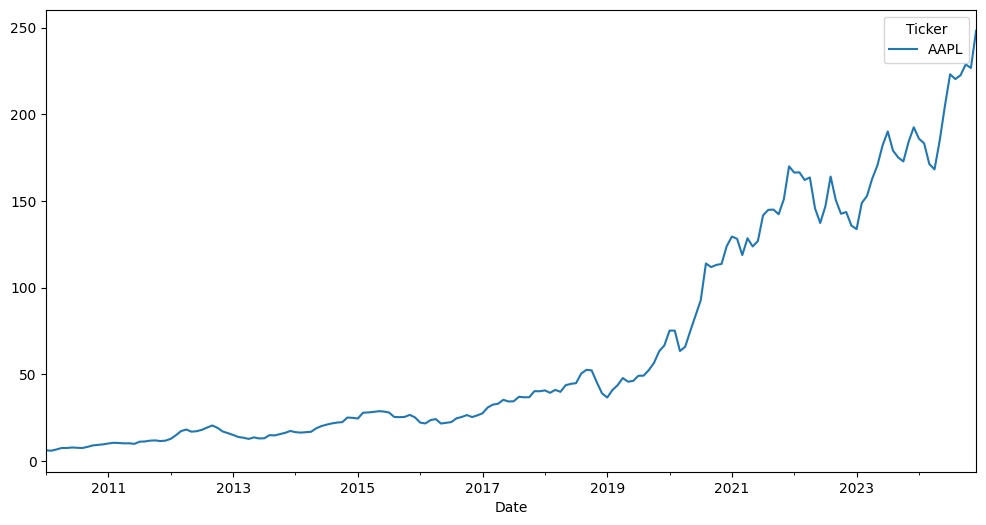

In [155]:
# RESampling 

df = yf.download("AAPL", start="2010-01-01", end="2025-01-01")
print(df.head())
df.xs("Close", axis=1, level='Price').resample("M").mean() # here we get the monthly price
df.xs("Close", axis=1, level='Price').resample("M").mean().plot(figsize=(12,6))
plt.show()



In [132]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.418385,6.433080,6.369499,6.400990,493729600
2010-01-05,6.429481,6.465770,6.395591,6.436079,601904800
2010-01-06,6.327211,6.454973,6.320613,6.429480,552160000
2010-01-07,6.315513,6.358101,6.269627,6.350603,477131200
2010-01-08,6.357502,6.358103,6.269929,6.307118,447610800


In [136]:
print(df.xs("Volume", axis=1, level='Price').resample("M").mean().reset_index()) # here we get the monthly volume average


df.xs("Volume", axis=1, level="Price").resample("M").sum().reset_index() # here we get the sum of the monthly volume

df.xs("Volume", axis=1, level="Price").resample("M").max().reset_index() # here we get the max of the monthly volume

Ticker       Date          AAPL
0      2010-01-31  7.983681e+08
1      2010-02-28  5.671621e+08
2      2010-03-31  5.284423e+08
3      2010-04-30  5.889109e+08
4      2010-05-31  9.041327e+08
..            ...           ...
175    2024-08-31  5.103032e+07
176    2024-09-30  6.160488e+07
177    2024-10-31  4.046678e+07
178    2024-11-30  4.457942e+07
179    2024-12-31  4.656743e+07

[180 rows x 2 columns]


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/796405165.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(df.xs("Volume", axis=1, level='Price').resample("M").mean().reset_index()) # here we get the monthly volume average
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/796405165.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.xs("Volume", axis=1, level="Price").resample("M").sum().reset_index() # here we get the sum of the monthly volume
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/796405165.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.xs("Volume", axis=1, level="Price").resample("M").max().reset_index() # here we get the max of the monthly volume


Ticker,Date,AAPL
0,2010-01-31,1867110000
1,2010-02-28,850306800
2,2010-03-31,920259200
3,2010-04-30,982391200
4,2010-05-31,1676018400
...,...,...
175,2024-08-31,119548600
176,2024-09-30,318679900
177,2024-10-31,64751400
178,2024-11-30,90152800


In [ ]:
# Extract each price type, resample, then combine
monthly = pd.concat([
    df.xs('Open', axis=1, level='Price').resample('M').first(),
    df.xs('High', axis=1, level='Price').resample('M').max(),
    df.xs('Low', axis=1, level='Price').resample('M').min(),
    df.xs('Close', axis=1, level='Price').resample('M').last(),
    df.xs('Volume', axis=1, level='Price').resample('M').mean()  # Changed from .sum() to .mean()
], axis=1, keys=['Open', 'High', 'Low', 'Close', 'Volume'])

In [158]:
monthly

,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-31,6.400990,6.465770,5.705796,5.760080,7.983681e+08
2010-02-28,5.769376,6.153263,5.723791,6.136768,5.671621e+08
2010-03-31,6.170657,7.122272,6.161660,7.047895,5.284423e+08
2010-04-30,7.120175,8.171357,6.980417,7.830362,5.889109e+08
2010-05-31,7.912834,8.033998,5.975715,7.704095,9.041327e+08
...,...,...,...,...,...
2024-08-31,222.856352,231.616486,194.677762,227.718430,5.103032e+07
2024-09-30,227.270936,231.785515,212.722813,231.696030,6.160488e+07


In [166]:
#  iterating over dataframe for math reasons

df_test= yf.download("^GSPC", start="2010-01-01", end="2025-01-01")
df_iter = df_test.copy()
df_iter.columns


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_3567/3288632007.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_test= yf.download("^GSPC", start="2010-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])

In [174]:
df_iter.columns.get_level_values('Price')
df_iter.columns = df_iter.columns.get_level_values('Price')
df_iter 

# We can iterate over the dataframe for math and research when evaluating.  NEVER IN PROD
# ex: when do we have a higher high than the previous day?

current_max = 0

for index, row in df_iter.iterrows():  #
    # print(index)
    if row.High > current_max:
        # print(f"New max found at {index}: {row.High}")
        current_max = row.High
        high_date = index


In [177]:
print(f"The highest high was {current_max} on {high_date.strftime("%Y-%m-%d")}")

The highest high was 6099.97021484375 on 2024-12-06


In [178]:
# NOW FOR THIS WE CAN VECTORIZE WHEN POSSIBLE 
df_iter.High.idxmax()

Timestamp('2024-12-06 00:00:00')